In [ ]:
print("Radhe Radhe")

Radhe Radhe


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Loading Data

In [ ]:
df=pd.read_csv("data.csv")

In [ ]:
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [ ]:
df.columns

Index(['policy_id', 'subscription_length', 'vehicle_age', 'customer_age',
       'region_code', 'region_density', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'steering_type', 'turning_radius', 'length',
       'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper',
       'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
       'is_power_door_locks', 'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status'],
      dtype='object')

In [ ]:
df.shape

(58592, 41)

# About Column

In [ ]:
# policy_id: Unique identifier for the insurance policy.
# subscription_length: The duration for which the insurance policy is active.
# vehicle_age: Age of the vehicle insured.
# customer_age: Age of the insurance policyholder.
# region_code: The code representing the geographical region of the policyholder.
# region_density: Population density of the policyholders region.
# segment: Segment of the vehicle.
# model: The model of the vehicle.
# fuel_type: Type of fuel the vehicle uses (e.g., Petrol, Diesel, CNG).
# max_torque, max_power: Engine performance characteristics.
# engine_type: The type of engine.
# airbags: The number of airbags in the vehicle.
# is_esc (Electronic Stability Control): is_adjustable_steering, is_tpms (Tire Pressure Monitoring System): Features that enhance vehicle safety.
# is_parking_sensors, is_parking_camera: Parking aids.
# rear_brakes_type: Type of rear brakes.
# displacement cylinder: Specifications related to the engine size and construction.
# transmission_type: Type of transmission.
# steering_type: Type of steering mechanism.
# turning_radius: Turning radius of the vehicle.
# length width gross_weight: Dimensions and weight of the vehicle.
# is_front_fog_lights, is_rear_window_wiper, is_rear_window_washer, is_rear_window_defogger, is_brake_assist, is_power_door_locks, is_central_locking, is_power_steering, is_driver_seat_height_adjustable, is_day_night_rear_view_mirror, is_ecw, is_speed_alert: Various binary indicators for specific vehicle amenities and safety features.
# ncap_rating: NCAP safety rating of the vehicle.
# claim_status: Indicates whether a claim was made (1) or not (0).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  object 
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   max_torque                        58592 non-null  object 
 10  max_power                         58592 non-null  object 
 11  engine_type                       58592 non-null  object 
 12  airb

In [ ]:
df.isna().sum().value_counts()

,count
0,41


In [ ]:
df.duplicated().value_counts()

,count
False,58592


In [ ]:
df.drop(columns='policy_id', axis=1, inplace=True)

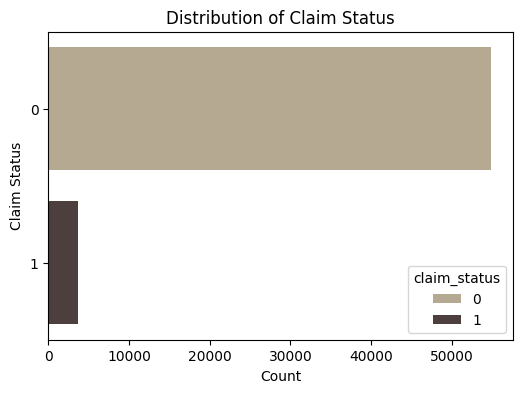

In [ ]:
# Creating a count plot to visualize the distribution of claim status
plt.figure(figsize=(6, 4))
sns.countplot(data=df, y='claim_status', hue='claim_status', palette=['#BBAB8C', '#503C3C'])
plt.xlabel('Count')
plt.ylabel('Claim Status')
plt.title('Distribution of Claim Status')
plt.show()

Dataset looks highly imbalance which might produce baisness , so we would use
1. oversampling
2. Undersampling

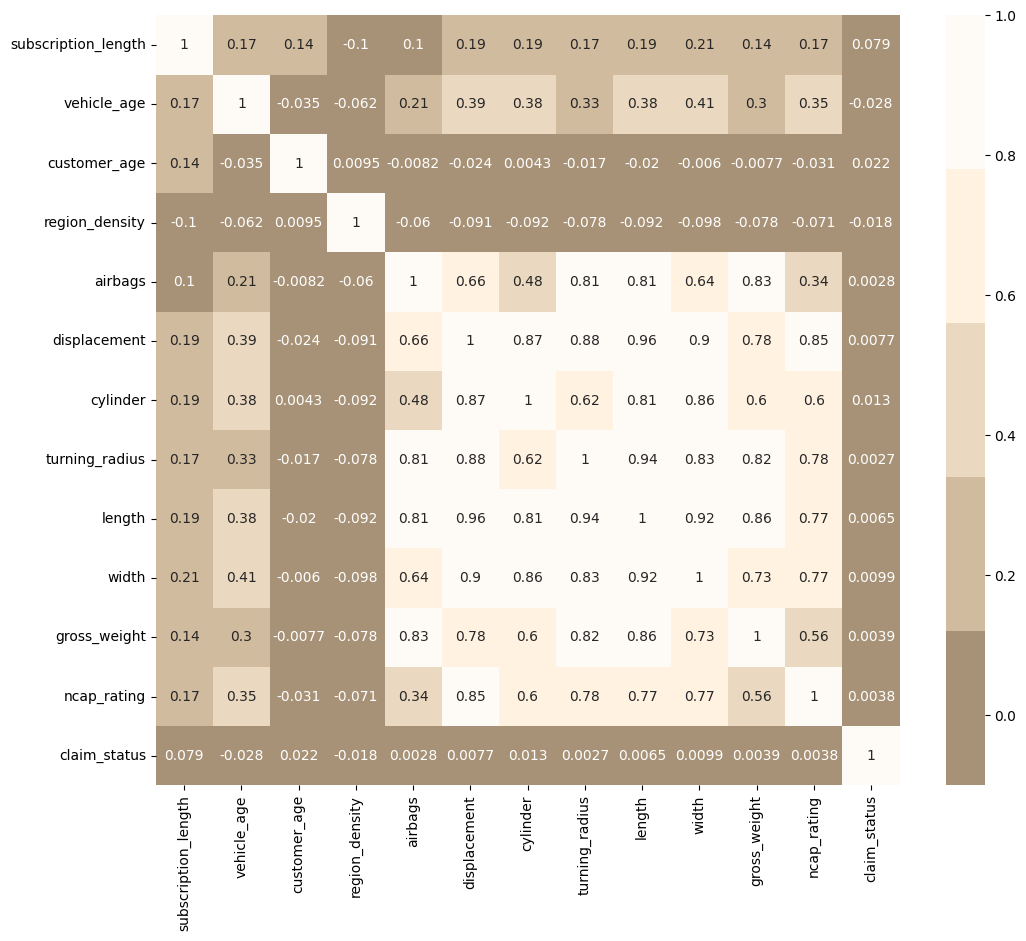

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap=['#A79277', '#D1BB9E', '#EAD8C0', '#FFF2E1', '#FEFAF6'])
plt.show()

# Oversampling

In [ ]:
minority=df[df['claim_status']==1]
majority=df[df['claim_status']==0]

In [ ]:
minority.sample()

,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
4117,7.7,0.0,62,C3,4076,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,...,No,No,No,Yes,No,No,No,Yes,0,1


In [ ]:
majority.sample()

,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
26968,2.2,0.8,49,C1,4990,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0


In [ ]:
from sklearn.utils import resample


In [ ]:
# Oversampling the minority class to balance the dataset
minority_ovs = resample(minority, replace=True, n_samples=len(majority), random_state=42)

In [ ]:
ovs_data=pd.concat([majority,minority_ovs])
ovs_data.sample(5)

,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
1107,7.4,1.6,39,C5,34738,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,...,No,No,No,Yes,No,No,No,Yes,0,1
31118,1.0,0.4,47,C8,8794,Utility,M10,CNG,85Nm@3000rpm,61.68bhp@6000rpm,...,No,No,No,No,No,No,No,Yes,0,0
9117,11.7,1.0,50,C22,16733,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
5350,3.5,2.6,40,C2,27003,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
41116,11.9,1.6,47,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,1


In [ ]:
ovs_data.claim_status.value_counts()

,count
claim_status,
0,54844
1,54844


In [ ]:
from sklearn.preprocessing import LabelEncoder
lbe=LabelEncoder()

In [ ]:
encoded_data = df.apply(lambda col: lbe.fit_transform(col) if col.dtype == 'object' else col)

In [ ]:
encoded_data.sample(5)

,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
22757,4.1,0.6,35,1,73430,0,0,0,5,2,...,0,0,0,1,0,0,0,1,0,0
28819,2.3,0.2,54,17,34738,0,0,0,5,2,...,0,0,0,1,0,0,0,1,0,0
21587,0.3,0.2,47,11,27003,0,0,0,5,2,...,0,0,0,1,0,0,0,1,0,0
48085,11.0,0.6,55,5,7788,2,7,2,0,6,...,1,1,1,1,1,1,1,1,2,0
34145,11.0,2.0,50,20,8794,1,9,0,6,3,...,0,1,1,1,0,0,1,1,2,0


In [ ]:
X = encoded_data.drop('claim_status', axis=1)
Y = encoded_data['claim_status']

In [ ]:
X_ovs_encoded = X_ovs.apply(lambda col: LabelEncoder().fit_transform(col) if col.dtype == 'object' else col)

In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
model_rf=RandomForestClassifier(random_state=42)

In [ ]:
model_rf.fit(X,Y)

RandomForestClassifier(random_state=42)

In [ ]:
# Get feature importances from the trained Random Forest model
feature_importance = model_rf.feature_importances_

In [ ]:
# Create a DataFrame to store feature names and their corresponding importances
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})

# Sort the DataFrame by feature importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
features_df.head(10)

,Feature,Importance
0,subscription_length,0.417150
2,customer_age,0.263397
1,vehicle_age,0.193724
4,region_density,0.059310
3,region_code,0.058201
6,model,0.000672
23,length,0.000639
24,width,0.000591
22,turning_radius,0.000504
25,gross_weight,0.000491


These results indicate that subscription length, customer age, and vehicle age are the most influential features in predicting insurance claims

In [ ]:
# Separating features (X) and target variable (y) from the oversampled dataset
X_ovs = ovs_data.drop('claim_status', axis=1)
y_ovs = ovs_data['claim_status']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Splitting the oversampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_ovs_encoded, y_ovs, test_size=0.3, random_state=42)

In [ ]:
# Instantiate the Random Forest classifier with a random state of 42
rf_model_oversampled = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rf_model_oversampled.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predicting the target variable for the test set using the trained model
y_pred = rf_model_oversampled.predict(X_test)

In [ ]:
# Print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     16574
           1       0.96      1.00      0.98     16333

    accuracy                           0.98     32907
   macro avg       0.98      0.98      0.98     32907
weighted avg       0.98      0.98      0.98     32907



In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
# Perform k-fold cross-validation
scores = cross_val_score(rf_model_oversampled, X_train, y_train, cv=5, scoring='accuracy')

# Print the mean accuracy and standard deviation of the cross-validation scores
print("Mean Accuracy:", scores.mean())
print("Standard Deviation of Accuracy:", scores.std())

Mean Accuracy: 0.9712949879182651
Standard Deviation of Accuracy: 0.0007218644273704443


In [ ]:
import pickle

with open("rf_model.pkl", "wb") as f:
    pickle.dump(model_rf, f)

with open("rf_model.pkl", "rb") as f:
    model = pickle.load(f)
